Attack saved Spambase model with varying attack percentages for both
aggressive and stealthy settings, then run k-rank defense before/after analysis.

In [1]:
import json
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn

In [2]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

DATA_DIR = Path("spambase_50_50")
MODEL_PATH = DATA_DIR / "spambase_mlp.pth"
PREPROC_PATH = DATA_DIR / "preprocessing.npz"
DATA_PATH = DATA_DIR / "train_test_data.npz"

OUTPUT_DIR = Path("experiments/attack_varying_pct") / datetime.now().strftime("%Y%m%d_%H%M%S")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

ATTACK_PERCENTAGES = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
MAXITERS = 300
ALPHA = 0.1
N_TRIALS = 10
ATTACK_CONFIGS = {
    'aggressive': 0.1,
    'stealthy': 50.0,
}
K_VALUES_TO_TEST = [1, 2, 3, 5, 10, 15, 20, 30, 40, 50, 57]

Device: cuda


In [3]:
class SpambaseNet(nn.Module):
    def __init__(self, D_in):
        super(SpambaseNet, self).__init__()
        self.layer = nn.Sequential(
            nn.Linear(D_in, 64), nn.ReLU(),
            nn.Linear(64, 32), nn.ReLU(),
            nn.Linear(32, 2), nn.Softmax(dim=-1)
        )

    def forward(self, x):
        if x.dim() == 1:
            x = x.unsqueeze(0)
            return self.layer(x).squeeze(0)
        return self.layer(x)


In [4]:
print("\nLoading model checkpoint...")
checkpoint = torch.load(MODEL_PATH, map_location=DEVICE)
model = SpambaseNet(D_in=57).to(DEVICE)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print(f"✓ Model loaded | Train Acc: {checkpoint.get('train_accuracy', 'N/A')}, Test Acc: {checkpoint.get('test_accuracy', 'N/A')}")

print("Loading test data...")
data = np.load(DATA_PATH)
X_test = data['X_test'].astype(np.float32)
y_test = data['y_test'].astype(np.int64)
print(f"✓ Test set: {X_test.shape}")

print("Loading preprocessing parameters...")
preproc = np.load(PREPROC_PATH)
weights = preproc['weights'].astype(np.float32)
bounds_min = preproc['bounds_min'].astype(np.float32)
bounds_max = preproc['bounds_max'].astype(np.float32)
bounds = [bounds_min, bounds_max]
print(f"✓ Bounds: [{bounds_min.min():.4f}, {bounds_max.max():.4f}], Weights shape: {weights.shape}")

# Get predictions and filter to correctly classified samples
print("\nFiltering to correctly classified samples...")
X_test_t = torch.FloatTensor(X_test).to(DEVICE)
with torch.no_grad():
    test_preds = model(X_test_t).argmax(dim=1).cpu().numpy()
correct_mask = (test_preds == y_test)
correct_indices = np.where(correct_mask)[0]
n_correct = len(correct_indices)

print(f"Total test samples: {len(X_test)}")
print(f"Correctly classified: {n_correct}/{len(X_test)} ({n_correct/len(X_test):.2%})")



Loading model checkpoint...
✓ Model loaded | Train Acc: 0.9108695652173913, Test Acc: 0.8996088657105606
Loading test data...
✓ Test set: (2301, 57)
Loading preprocessing parameters...
✓ Bounds: [0.0000, 1.0000], Weights shape: (57,)

Filtering to correctly classified samples...
Total test samples: 2301
Correctly classified: 2070/2301 (89.96%)


In [5]:
def clip(current, low_bound, up_bound, device):
    low_bound = torch.FloatTensor(low_bound).to(device)
    up_bound = torch.FloatTensor(up_bound).to(device)
    return torch.max(torch.min(current, up_bound), low_bound)


def lowProFool_gpu(x, model, weights, bounds, maxiters, alpha, lambda_, device):
    x = x.to(device)
    v = torch.FloatTensor(np.array(weights)).to(device)
    r = torch.FloatTensor(1e-4 * np.ones(x.shape)).to(device)
    r.requires_grad = True

    with torch.no_grad():
        output = model(x)
        orig_pred = output.argmax().cpu().item()

    target_pred = 1 - orig_pred
    target = torch.tensor([0., 1.] if target_pred == 1 else [1., 0.]).to(device)
    bce = nn.BCELoss()

    for _ in range(maxiters):
        if r.grad is not None:
            r.grad.zero_()
        output = model(x + r)
        loss_bce = bce(output, target)
        loss_l2 = torch.sqrt(torch.sum((v * r) ** 2))
        loss = loss_bce + lambda_ * loss_l2
        loss.backward(retain_graph=True)
        with torch.no_grad():
            r_new = r - alpha * r.grad
        r = r_new.clone().detach().requires_grad_(True)

    x_adv = clip(x + r, bounds[0], bounds[1], device)
    with torch.no_grad():
        adv_pred = model(x_adv).argmax().cpu().item()

    return orig_pred, adv_pred, x_adv.detach().cpu().numpy()

In [6]:
def k_rank_approximation(data_matrix, k):
    U, s, Vh = np.linalg.svd(data_matrix, full_matrices=False)
    k_use = min(k, len(s))
    U_k = U[:, :k_use]
    s_k = s[:k_use]
    Vh_k = Vh[:k_use, :]
    return U_k @ np.diag(s_k) @ Vh_k


def predict_labels(x_np, model, device):
    model.eval()
    with torch.no_grad():
        x_t = torch.FloatTensor(x_np).to(device)
        return model(x_t).argmax(dim=1).cpu().numpy()

In [7]:
np.random.seed(42)
n_max_attack = int(np.ceil(len(correct_indices) * max(ATTACK_PERCENTAGES) / 100.0))
attack_indices = np.random.choice(correct_indices, size=n_max_attack, replace=False)
X_orig = X_test[attack_indices]

print(f"\nAttack percentages: {ATTACK_PERCENTAGES}")
print(f"Attack types: {list(ATTACK_CONFIGS.keys())}")
print(f"Max attacked samples: {n_max_attack}/{n_correct}")
print(f"Trials per percentage: {N_TRIALS}")

np.save(OUTPUT_DIR / "all_attacked_indices.npy", attack_indices)



Attack percentages: [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
Attack types: ['aggressive', 'stealthy']
Max attacked samples: 2070/2070
Trials per percentage: 10



Running attack type: aggressive (lambda=0.1)
  [1/2070]   [2/2070]   [3/2070]   [4/2070]   [5/2070]   [100/2070] success=True
  [200/2070] success=True
  [300/2070] success=True
  [400/2070] success=True
  [500/2070] success=True
  [600/2070] success=True
  [700/2070] success=True
  [800/2070] success=True
  [900/2070] success=True
  [1000/2070] success=True
  [1100/2070] success=True
  [1200/2070] success=True
  [1300/2070] success=True
  [1400/2070] success=True
  [1500/2070] success=True
  [1600/2070] success=True
  [1700/2070] success=True
  [1800/2070] success=True
  [1900/2070] success=True
  [2000/2070] success=True
  [2070/2070] success=True

✓ aggressive: generated 2070 adversarial samples

Computing attack success rates...
   10% | success=100.00%±0.00%
   20% | success=100.00%±0.00%
   30% | success=100.00%±0.00%
   40% | success=100.00%±0.00%
   50% | success=100.00%±0.00%
   60% | success=100.00%±0.00%
   70% | success=100.00%±0.00%
   80% | success=100.00%±0.00%
   90% |

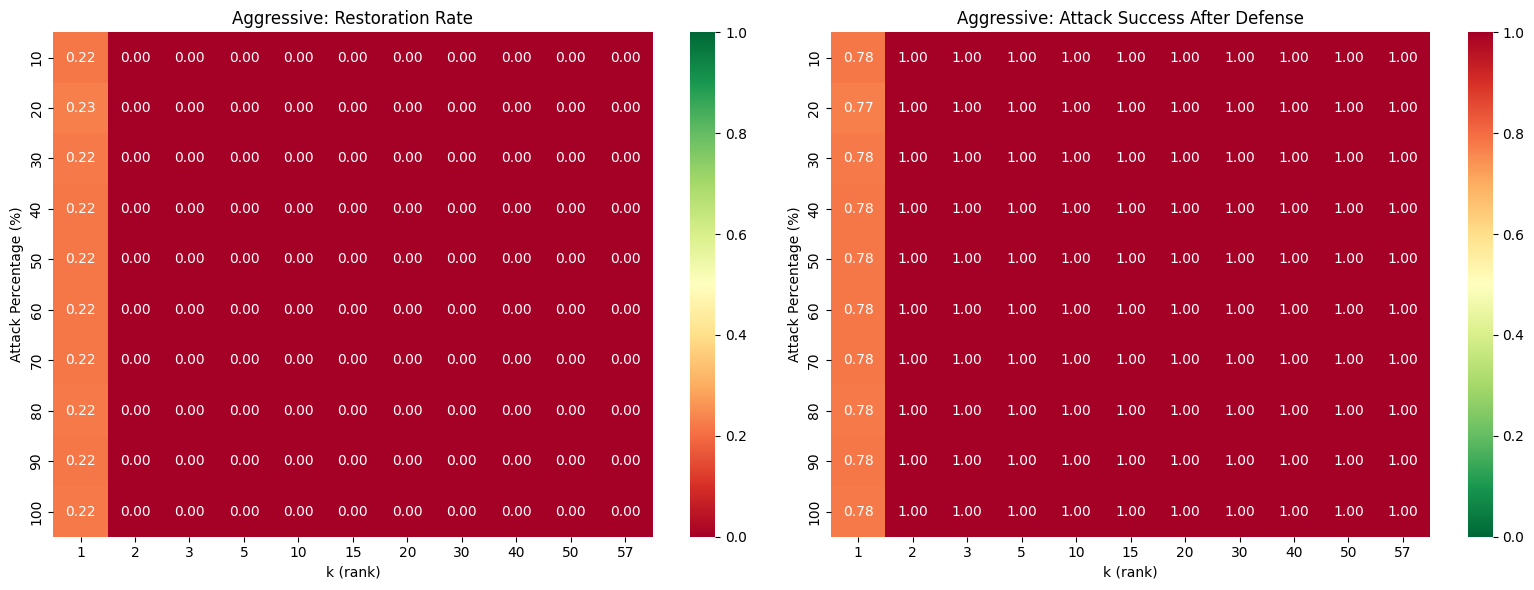

✓ aggressive: saved outputs to experiments/attack_varying_pct/20260504_134847/aggressive

Running attack type: stealthy (lambda=50.0)
  [1/2070]   [2/2070]   [3/2070]   [4/2070]   [5/2070]   [100/2070] success=True
  [200/2070] success=True
  [300/2070] success=True
  [400/2070] success=True
  [500/2070] success=True
  [600/2070] success=True
  [700/2070] success=True
  [800/2070] success=True
  [900/2070] success=True
  [1000/2070] success=True
  [1100/2070] success=True
  [1200/2070] success=True
  [1300/2070] success=True
  [1400/2070] success=True
  [1500/2070] success=True
  [1600/2070] success=True
  [1700/2070] success=True
  [1800/2070] success=True
  [1900/2070] success=True
  [2000/2070] success=True
  [2070/2070] success=True

✓ stealthy: generated 2070 adversarial samples

Computing attack success rates...
   10% | success=98.74%±0.66%
   20% | success=98.94%±0.55%
   30% | success=99.05%±0.33%
   40% | success=98.94%±0.26%
   50% | success=98.99%±0.26%
   60% | success=98.

<Figure size 640x480 with 0 Axes>

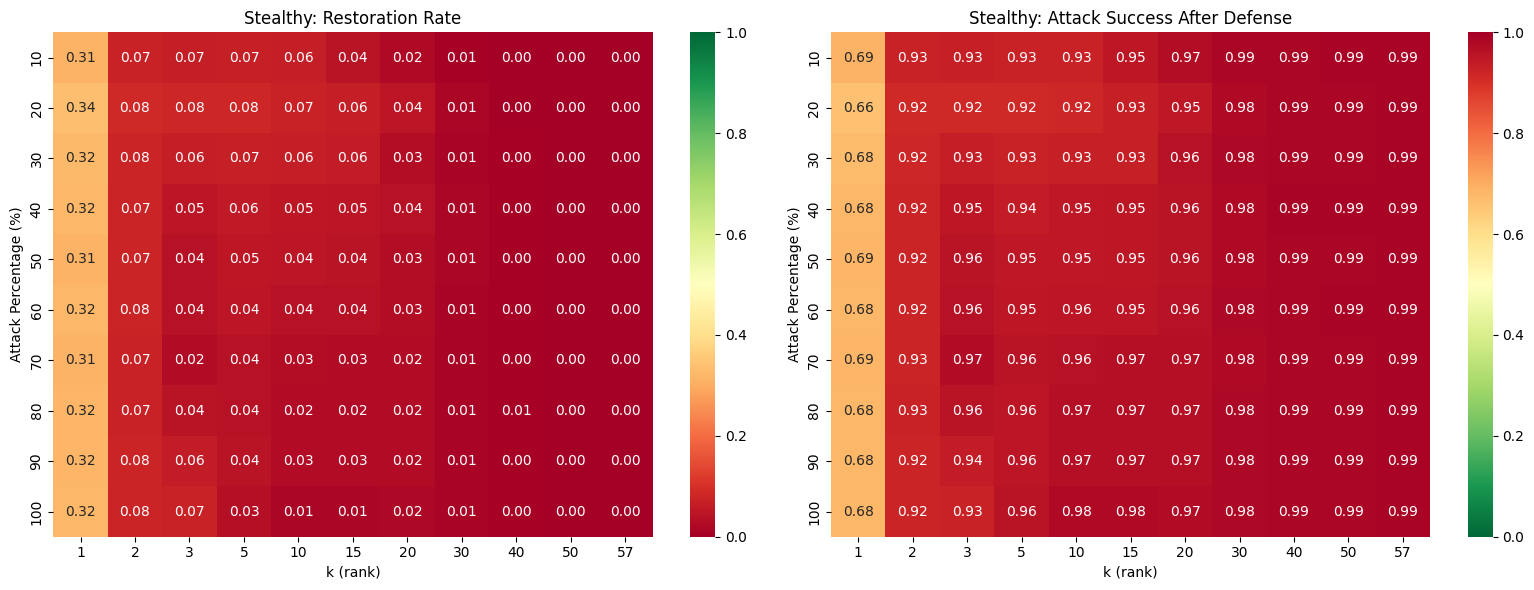

✓ stealthy: saved outputs to experiments/attack_varying_pct/20260504_134847/stealthy

✓ All results saved
Output root: experiments/attack_varying_pct/20260504_134847
Includes per-attack folders:
  - aggressive/summary.json
  - aggressive/k_rank_before_after.csv
  - aggressive/k_rank_before_after_heatmaps.png
  - stealthy/summary.json
  - stealthy/k_rank_before_after.csv
  - stealthy/k_rank_before_after_heatmaps.png


<Figure size 640x480 with 0 Axes>

In [8]:
for attack_name, lambda_val in ATTACK_CONFIGS.items():
    print("\n" + "=" * 70)
    print(f"Running attack type: {attack_name} (lambda={lambda_val})")
    print("=" * 70)

    attack_dir = OUTPUT_DIR / attack_name
    attack_dir.mkdir(parents=True, exist_ok=True)

    # Generate adversarial examples
    X_adv = np.zeros_like(X_orig)
    y_orig = np.zeros(n_max_attack, dtype=int)
    y_adv = np.zeros(n_max_attack, dtype=int)
    perturbations = np.zeros_like(X_adv)

    for i, idx in enumerate(attack_indices):
        if (i + 1) % 100 == 0 or i < 5 or i == n_max_attack - 1:
            print(f"  [{i + 1}/{n_max_attack}]", end=" ", flush=True)

        x = torch.tensor(X_test[idx], device=DEVICE)
        y_orig_i, y_adv_i, x_adv_i = lowProFool_gpu(
            x, model, weights, bounds, MAXITERS, ALPHA, lambda_val, DEVICE
        )

        X_adv[i] = x_adv_i
        y_orig[i] = y_orig_i
        y_adv[i] = y_adv_i
        perturbations[i] = x_adv_i - X_test[idx]

        if (i + 1) % 100 == 0 or i == n_max_attack - 1:
            print(f"success={y_orig_i != y_adv_i}")

    print(f"\n✓ {attack_name}: generated {n_max_attack} adversarial samples")

    # Compute attack success rates by percentage
    print(f"\nComputing attack success rates...")
    attack_results = {}

    for pct in ATTACK_PERCENTAGES:
        n_attack = int(np.ceil(n_correct * pct / 100.0))
        success_rates = []

        for trial in range(N_TRIALS):
            np.random.seed(1000 + pct * 100 + trial)
            idx_subset = np.random.choice(n_max_attack, size=min(n_attack, n_max_attack), replace=False)

            success_rate = np.mean(y_orig[idx_subset] != y_adv[idx_subset])
            success_rates.append(float(success_rate))

        attack_results[pct] = {
            'success_rate_mean': float(np.mean(success_rates)),
            'success_rate_std': float(np.std(success_rates)),
        }

        print(f"  {pct:3d}% | success={np.mean(success_rates):.2%}±{np.std(success_rates):.2%}")

    # Evaluate k-rank defense
    print(f"\nEvaluating k-rank defense...")
    k_rank_results = []

    for pct in ATTACK_PERCENTAGES:
        n_attack = int(np.ceil(n_correct * pct / 100.0))
        
        for trial in range(N_TRIALS):
            np.random.seed(5000 + pct * 100 + trial)
            idx_subset = np.random.choice(n_max_attack, size=min(n_attack, n_max_attack), replace=False)

            X_orig_subset = X_orig[idx_subset]
            X_adv_subset = X_adv[idx_subset]
            y_orig_subset = y_orig[idx_subset]

            y_adv_pred = predict_labels(X_adv_subset, model, DEVICE)
            attack_success = np.mean(y_orig_subset != y_adv_pred)
            successful_idx = (y_orig_subset != y_adv_pred)

            for k in K_VALUES_TO_TEST:
                X_defended = k_rank_approximation(X_adv_subset, k)
                X_defended = np.clip(X_defended, bounds[0], bounds[1])
                y_defended = predict_labels(X_defended, model, DEVICE)

                if successful_idx.sum() > 0:
                    restoration = np.mean(y_defended[successful_idx] == y_orig_subset[successful_idx])
                else:
                    restoration = 0.0

                k_rank_results.append({
                    'attack_pct': pct,
                    'trial': trial,
                    'k': k,
                    'attack_success_before': attack_success,
                    'attack_success_after': np.mean(y_orig_subset != y_defended),
                    'restoration_rate': restoration,
                })

    df_results = pd.DataFrame(k_rank_results)

    # Save arrays
    print(f"\nSaving {attack_name} results...")
    np.save(attack_dir / "original_samples.npy", X_orig)
    np.save(attack_dir / "adversarial_samples.npy", X_adv)
    np.save(attack_dir / "original_predictions.npy", y_orig)
    np.save(attack_dir / "adversarial_predictions.npy", y_adv)
    np.save(attack_dir / "perturbations.npy", perturbations)

    # Save attack results
    with open(attack_dir / "summary.json", "w") as f:
        json.dump({
            'attack_type': attack_name,
            'lambda': float(lambda_val),
            'attack_results': attack_results,
        }, f, indent=2)

    # Save k-rank results
    df_grouped = df_results.groupby(['attack_pct', 'k']).mean(numeric_only=True).reset_index()
    df_grouped.to_csv(attack_dir / "k_rank_before_after.csv", index=False)
    df_results.to_csv(attack_dir / "k_rank_before_after_detailed.csv", index=False)

    # Create heatmaps
    pivot_restoration = df_grouped.pivot(index='attack_pct', columns='k', values='restoration_rate')
    pivot_attack_after = df_grouped.pivot(index='attack_pct', columns='k', values='attack_success_after')

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    sns.heatmap(pivot_restoration, ax=axes[0], annot=True, fmt='.2f', cmap='RdYlGn', vmin=0, vmax=1)
    axes[0].set_title(f'{attack_name.title()}: Restoration Rate')
    axes[0].set_xlabel('k (rank)')
    axes[0].set_ylabel('Attack Percentage (%)')

    sns.heatmap(pivot_attack_after, ax=axes[1], annot=True, fmt='.2f', cmap='RdYlGn_r', vmin=0, vmax=1)
    axes[1].set_title(f'{attack_name.title()}: Attack Success After Defense')
    axes[1].set_xlabel('k (rank)')
    axes[1].set_ylabel('Attack Percentage (%)')

    plt.tight_layout()
    plt.show()
    plt.savefig(attack_dir / "k_rank_before_after_heatmaps.png", dpi=150, bbox_inches='tight')
    plt.close(fig)

    print(f"✓ {attack_name}: saved outputs to {attack_dir}")


print("\n✓ All results saved")
print(f"Output root: {OUTPUT_DIR}")
print("Includes per-attack folders:")
for attack_name in ATTACK_CONFIGS:
    print(f"  - {attack_name}/summary.json")
    print(f"  - {attack_name}/k_rank_before_after.csv")
    print(f"  - {attack_name}/k_rank_before_after_heatmaps.png")
